# Cellule 1 — Installer les dépendances


In [1]:
!pip install transformers sentencepiece -q

# Cellule 1 — Setup et clone du repo

In [2]:
import os, sys

# Clone le repo si pas déjà présent
if not os.path.exists('/kaggle/working/sign-language-production'):
    os.system('git clone https://github.com/sarrazer24/sign-language-production.git /kaggle/working/sign-language-production')

# Vérifier que les fichiers sont là
data_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data'
print("Fichiers disponibles :", os.listdir(data_path))

Cloning into '/kaggle/working/sign-language-production'...


Fichiers disponibles : ['stats.pt', 'normalize.py', 'collate.py', 'dataset.py']


# Cellule 2 — Imports

In [3]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from transformers import T5EncoderModel, T5Tokenizer
import csv
from tqdm import tqdm

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_KP     = 151
POSE_DIM = N_KP * 3   # 453
BASE     = "/kaggle/input/datasets/sarraverse/how2signdataset"

print(f"Device : {DEVICE}")

Device : cuda


# Cellule 3 — Dataset et DataLoader

In [4]:
from transformers import T5Tokenizer

class How2SignDataset(Dataset):
    def __init__(self, split='train', stats=None, max_frames=500):
        assert split in ['train', 'dev', 'test']
        self.max_frames  = max_frames
        self.n_keypoints = N_KP

        with open(f"{BASE}/{split}.skels", 'r') as f:
            self.skels_lines = f.readlines()
        with open(f"{BASE}/{split}.text", 'r', encoding='utf-8') as f:
            self.text_lines = f.readlines()
        with open(f"{BASE}/{split}.files", 'r') as f:
            self.files_lines = f.readlines()

        self.tokenizer = T5Tokenizer.from_pretrained('t5-small')
        self.stats = stats

    def __len__(self):
        return len(self.skels_lines)

    def __getitem__(self, idx):
        vals     = np.array(self.skels_lines[idx].strip().split(), dtype=np.float32)
        n_frames = len(vals) // (self.n_keypoints * 3)
        poses    = vals[:n_frames * self.n_keypoints * 3].reshape(n_frames, self.n_keypoints, 3)

        if n_frames > self.max_frames:
            poses    = poses[:self.max_frames]
            n_frames = self.max_frames

        if self.stats is not None:
            poses = (poses - self.stats['mean'].numpy()) / \
                    (self.stats['std'].numpy() + 1e-8)

        poses = torch.FloatTensor(poses)

        text = self.text_lines[idx].strip()
        enc  = self.tokenizer(
            text, return_tensors='pt',
            padding=False, truncation=True, max_length=200
        )

        return {
            'poses'         : poses,
            'pose_length'   : n_frames,
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'text'          : text,
            'file_ref'      : self.files_lines[idx].strip()
        }


def collate_fn(batch):
    batch        = sorted(batch, key=lambda x: x['pose_length'], reverse=True)
    pose_lengths = torch.LongTensor([item['pose_length'] for item in batch])
    T_max        = pose_lengths[0].item()
    B            = len(batch)
    K            = batch[0]['poses'].shape[1]

    poses_padded = torch.zeros(B, T_max, K, 3)
    pose_mask    = torch.zeros(B, T_max, dtype=torch.bool)
    for i, item in enumerate(batch):
        T = item['pose_length']
        poses_padded[i, :T] = item['poses']
        pose_mask[i, :T]    = True

    input_ids = torch.nn.utils.rnn.pad_sequence(
        [item['input_ids'] for item in batch],
        batch_first=True, padding_value=0
    )
    attention_mask = torch.nn.utils.rnn.pad_sequence(
        [item['attention_mask'] for item in batch],
        batch_first=True, padding_value=0
    )

    return {
        'poses'         : poses_padded,
        'pose_mask'     : pose_mask,
        'pose_lengths'  : pose_lengths,
        'input_ids'     : input_ids,
        'attention_mask': attention_mask,
        'texts'         : [item['text'] for item in batch]
    }

# Cellule 4 — Charger stats.pt et créer les DataLoaders


In [5]:
# Charger stats.pt depuis le repo cloné
stats_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/stats.pt'

# Si stats.pt n'est pas dans le repo, le recalculer
if os.path.exists(stats_path):
    stats = torch.load(stats_path)
    print("✅ stats.pt chargé depuis le repo")
else:
    print("⚠️ stats.pt introuvable — recalcul en cours...")
    all_poses = []
    with open(f"{BASE}/train.skels", 'r') as f:
        for i, line in enumerate(f):
            if i >= 5000:
                break
            vals    = np.array(line.strip().split(), dtype=np.float32)
            n_frames = len(vals) // (N_KP * 3)
            if n_frames == 0:
                continue
            poses = vals[:n_frames * N_KP * 3].reshape(n_frames, N_KP, 3)
            all_poses.append(poses[:100])
    all_poses = np.concatenate(all_poses, axis=0)
    stats = {
        'mean': torch.FloatTensor(all_poses.mean(axis=0)),
        'std' : torch.FloatTensor(all_poses.std(axis=0))
    }
    torch.save(stats, stats_path)
    print("✅ stats.pt recalculé et sauvegardé")

train_ds = How2SignDataset('train', stats=stats, max_frames=500)
dev_ds   = How2SignDataset('dev',   stats=stats, max_frames=500)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
dev_loader   = DataLoader(dev_ds,   batch_size=16, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

print(f"Train : {len(train_ds)} samples — {len(train_loader)} batches")
print(f"Dev   : {len(dev_ds)}   samples — {len(dev_loader)}   batches")

# Vérification rapide
batch = next(iter(train_loader))
print(f"Batch poses shape : {batch['poses'].shape}")
print(f"Batch texte[0]    : {batch['texts'][0][:60]}")

✅ stats.pt chargé depuis le repo


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train : 31046 samples — 1941 batches
Dev   : 1739   samples — 109   batches
Batch poses shape : torch.Size([16, 138, 151, 3])
Batch texte[0]    : "The colors were so expensive that they quit making colored 


# Cellule 5 — Bloc 1 : TextEncoder


In [6]:
class TextEncoder(nn.Module):
    def __init__(self, model_name='t5-small', output_dim=512):
        super().__init__()
        self.encoder = T5EncoderModel.from_pretrained(model_name)

        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.encoder.encoder.block[-2:].parameters():
            param.requires_grad = True

        hidden_size = self.encoder.config.d_model
        self.proj   = nn.Linear(hidden_size, output_dim) \
                      if hidden_size != output_dim else nn.Identity()

    def forward(self, input_ids, attention_mask):
        outputs       = self.encoder(input_ids=input_ids,
                                     attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state
        mask          = attention_mask.unsqueeze(-1).float()
        pooled        = (hidden_states * mask).sum(1) / mask.sum(1).clamp(1e-9)
        return self.proj(pooled)                            # (B, 512)

# Cellule 6 — Bloc 2 : TimestepEmbedding


In [7]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def sinusoidal_embedding(self, timesteps):
        device = timesteps.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -math.log(10000) *
            torch.arange(half, device=device) / (half - 1)
        )
        args = timesteps[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    def forward(self, timesteps):
        return self.mlp(self.sinusoidal_embedding(timesteps))  # (B, 512)

# Cellule 7 — Bloc 3 : SemanticTimestepConditioning


In [8]:
class SemanticTimestepConditioning(nn.Module):
    def __init__(self, dim=512, num_heads=8):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, batch_first=True
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def forward(self, t_embd, c_embd):
        t        = t_embd.unsqueeze(1)
        c        = c_embd.unsqueeze(1)
        attn_out, _ = self.cross_attn(query=t, key=c, value=c)
        t        = self.norm1(t + attn_out)
        t        = self.norm2(t + self.ffn(t))
        return t.squeeze(1)                                    # (B, 512)

# Cellule 8 — Bloc 4 : UNet1D


In [9]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim=512):
        super().__init__()
        self.conv1     = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.conv2     = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.cond_proj = nn.Linear(cond_dim, out_ch * 2)
        self.norm1     = nn.GroupNorm(8, out_ch)
        self.norm2     = nn.GroupNorm(8, out_ch)
        self.act       = nn.SiLU()
        self.res_proj  = nn.Conv1d(in_ch, out_ch, 1) \
                         if in_ch != out_ch else nn.Identity()

    def forward(self, x, z_c):
        h            = self.act(self.norm1(self.conv1(x)))
        scale, shift = self.cond_proj(z_c).chunk(2, dim=-1)
        h            = h * (1 + scale.unsqueeze(-1)) + shift.unsqueeze(-1)
        h            = self.act(self.norm2(self.conv2(h)))
        return h + self.res_proj(x)


class UNet1D(nn.Module):
    def __init__(self, pose_dim=453, cond_dim=512, base_ch=128):
        super().__init__()
        C = base_ch
        self.input_proj  = nn.Conv1d(pose_dim, C, 1)
        self.enc1        = ResBlock1D(C,     C,     cond_dim)
        self.enc2        = ResBlock1D(C,     C * 2, cond_dim)
        self.enc3        = ResBlock1D(C * 2, C * 4, cond_dim)
        self.down1       = nn.Conv1d(C,     C,     3, stride=2, padding=1)
        self.down2       = nn.Conv1d(C * 2, C * 2, 3, stride=2, padding=1)
        self.down3       = nn.Conv1d(C * 4, C * 4, 3, stride=2, padding=1)
        self.bottleneck  = ResBlock1D(C * 4, C * 4, cond_dim)
        self.dec3        = ResBlock1D(C * 8, C * 4, cond_dim)
        self.dec2        = ResBlock1D(C * 6, C * 2, cond_dim)
        self.dec1        = ResBlock1D(C * 3, C,     cond_dim)
        self.up3         = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up2         = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up1         = nn.ConvTranspose1d(C * 2, C * 2, 4, stride=2, padding=1)
        self.output_proj = nn.Conv1d(C, pose_dim, 1)

    def _match_size(self, x, target):
        """Tronque x pour matcher la taille temporelle de target"""
        if x.shape[2] != target.shape[2]:
            x = x[:, :, :target.shape[2]]
        return x

    def forward(self, x, z_c):
        x  = self.input_proj(x.transpose(1, 2))
        s1 = self.enc1(x,  z_c);  x = self.down1(s1)
        s2 = self.enc2(x,  z_c);  x = self.down2(s2)
        s3 = self.enc3(x,  z_c);  x = self.down3(s3)
        x  = self.bottleneck(x, z_c)
        x  = self.dec3(torch.cat([self._match_size(self.up3(x), s3), s3], dim=1), z_c)
        x  = self.dec2(torch.cat([self._match_size(self.up2(x), s2), s2], dim=1), z_c)
        x  = self.dec1(torch.cat([self._match_size(self.up1(x), s1), s1], dim=1), z_c)
        return self.output_proj(x).transpose(1, 2)

# Cellule 9 — Bloc 5 : GaussianDiffusion


In [10]:
class GaussianDiffusion(nn.Module):
    def __init__(self, model, T=100):
        super().__init__()
        self.model = model
        self.T     = T

        betas          = self._cosine_schedule(T)
        alphas         = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas',          betas)
        self.register_buffer('alphas',         alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('sqrt_acp',       torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus', torch.sqrt(1 - alphas_cumprod))

    def _cosine_schedule(self, T, s=0.008):
        steps = torch.arange(T + 1, dtype=torch.float32)
        f     = torch.cos((steps / T + s) / (1 + s) * math.pi / 2) ** 2
        betas = 1 - f[1:] / f[:-1]
        return torch.clamp(betas, 0.0001, 0.9999)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        s  = self.sqrt_acp[t][:, None, None]
        sm = self.sqrt_one_minus[t][:, None, None]
        return s * x0 + sm * noise, noise

    def compute_loss(self, x0, z_c, pose_mask):
        B          = x0.shape[0]
        t          = torch.randint(0, self.T, (B,), device=x0.device)
        x_t, noise = self.q_sample(x0, t)
        noise_pred = self.model(x_t, z_c)
        mask       = pose_mask.unsqueeze(-1).float()
        return ((noise_pred - noise) ** 2 * mask).sum() / mask.sum()

    @torch.no_grad()
    def p_sample(self, x_t, t_val, z_c):
        t        = torch.full((x_t.shape[0],), t_val,
                              device=x_t.device, dtype=torch.long)
        beta     = self.betas[t][:, None, None]
        alpha    = self.alphas[t][:, None, None]
        alpha_cp = self.alphas_cumprod[t][:, None, None]
        pred     = self.model(x_t, z_c)

        # Clipper le bruit prédit pour éviter l'explosion
        pred = torch.clamp(pred, -1.0, 1.0)

        coef = beta / torch.sqrt(1 - alpha_cp)
        mean = (1 / torch.sqrt(alpha)) * (x_t - coef * pred)

        # Clipper x_{t-1} pour rester dans une plage raisonnable
        mean = torch.clamp(mean, -10.0, 10.0)

        if t_val > 0:
            mean = mean + torch.sqrt(beta) * torch.randn_like(x_t)

        return mean

    @torch.no_grad()
    def sample(self, z_c, n_frames):
        x = torch.randn(z_c.shape[0], n_frames, POSE_DIM, device=z_c.device)
        for t in reversed(range(self.T)):
            x = self.p_sample(x, t, z_c)
        return x

# Cellule 10 — Modèle complet ApproachB


In [11]:
class ApproachB(nn.Module):
    def __init__(self, T=100, use_contribution=True):
        super().__init__()
        self.use_contribution = use_contribution
        self.text_encoder     = TextEncoder()
        self.timestep_emb     = TimestepEmbedding(dim=512)
        self.semantic_cond    = SemanticTimestepConditioning(dim=512)
        self.unet             = UNet1D(pose_dim=POSE_DIM, base_ch=64)
        self.diffusion        = GaussianDiffusion(self.unet, T=T)
        self.naive_proj       = nn.Linear(512, 512)

    def get_condition(self, t_embd, c_embd):
        if self.use_contribution:
            return self.semantic_cond(t_embd, c_embd)
        else:
            return self.naive_proj(t_embd + c_embd)

    def forward(self, batch):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        poses          = batch['poses'].to(DEVICE)
        pose_mask      = batch['pose_mask'].to(DEVICE)

        B, T, K, _  = poses.shape
        x0          = poses.reshape(B, T, K * 3)
        c_embd      = self.text_encoder(input_ids, attention_mask)
        t           = torch.randint(0, self.diffusion.T, (B,), device=DEVICE)
        t_embd      = self.timestep_emb(t)
        z_c         = self.get_condition(t_embd, c_embd)
        return self.diffusion.compute_loss(x0, z_c, pose_mask)

    @torch.no_grad()
    def generate(self, input_ids, attention_mask, n_frames=55):
        self.eval()
        c_embd = self.text_encoder(input_ids, attention_mask)
        t_zero = torch.zeros(c_embd.shape[0], device=DEVICE, dtype=torch.long)
        t_embd = self.timestep_emb(t_zero)
        z_c    = self.get_condition(t_embd, c_embd)
        poses  = self.diffusion.sample(z_c, n_frames)
        return poses.reshape(-1, n_frames, N_KP, 3)


# Test rapide avant d'entraîner
model = ApproachB(T=100, use_contribution=True).to(DEVICE)
batch = next(iter(train_loader))
loss  = model(batch)
print(f"✅ Forward pass OK — loss initiale : {loss.item():.4f}")
print(f"Paramètres entraînables : "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

✅ Forward pass OK — loss initiale : 554.2214
Paramètres entraînables : 13,661,701


# Cellule 11 — Fonctions d'entraînement et d'évaluation


In [12]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss = model(batch)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    for batch in tqdm(loader, desc="Eval", leave=False):
        with torch.cuda.amp.autocast():
            loss = model(batch)
        total_loss += loss.item()
    return total_loss / len(loader)

# Cellule 12 — Lancement entraînement


In [13]:
def run_training(use_contribution=True, n_epochs=100, lr=1e-5, tag="with_contrib"):
    model     = ApproachB(T=100, use_contribution=use_contribution).to(DEVICE)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-2
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-6
    )
    scaler  = torch.cuda.amp.GradScaler()
    history = {'train': [], 'dev': []}
    best_dev_loss = float('inf')

    print(f"\n{'='*50}")
    print(f"Entraînement — {tag}")
    print(f"Paramètres entraînables : "
          f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*50}\n")

    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        dev_loss   = evaluate(model, dev_loader)
        scheduler.step()
        history['train'].append(train_loss)
        history['dev'].append(dev_loss)
        print(f"Epoch {epoch:3d}/{n_epochs} | "
              f"Train: {train_loss:.4f} | Dev: {dev_loss:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.2e}")
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            torch.save(model.state_dict(), f'/kaggle/working/best_{tag}.pt')
            print(f"  ✅ Checkpoint sauvegardé (dev={dev_loss:.4f})")

    return model, history


model_with,    history_with    = run_training(use_contribution=True,
                                               n_epochs=100,
                                               lr=1e-5,
                                               tag="with_contrib")
model_without, history_without = run_training(use_contribution=False,
                                               n_epochs=100,
                                               lr=1e-5,
                                               tag="without_contrib")

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

/tmp/ipykernel_24/2244240959.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler()



Entraînement — with_contrib
Paramètres entraînables : 13,661,701



Train:   0%|          | 0/1941 [00:00<?, ?it/s]/tmp/ipykernel_24/3166220761.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval:   0%|          | 0/109 [00:00<?, ?it/s]/tmp/ipykernel_24/3166220761.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch   1/100 | Train: 452.3111 | Dev: 443.1704 | LR: 1.00e-05
  ✅ Checkpoint sauvegardé (dev=443.1704)


...

Epoch  96/100 | Train: 391.9500 | Dev: 392.3402 | LR: 1.04e-06


Epoch  97/100 | Train: 391.8977 | Dev: 392.4020 | LR: 1.02e-06


Epoch  98/100 | Train: 391.8570 | Dev: 392.5834 | LR: 1.01e-06


Epoch  99/100 | Train: 391.9079 | Dev: 392.3418 | LR: 1.00e-06


Epoch 100/100 | Train: 391.9512 | Dev: 392.3918 | LR: 1.00e-06


# Cellule 13 — Courbe de convergence (log scale)


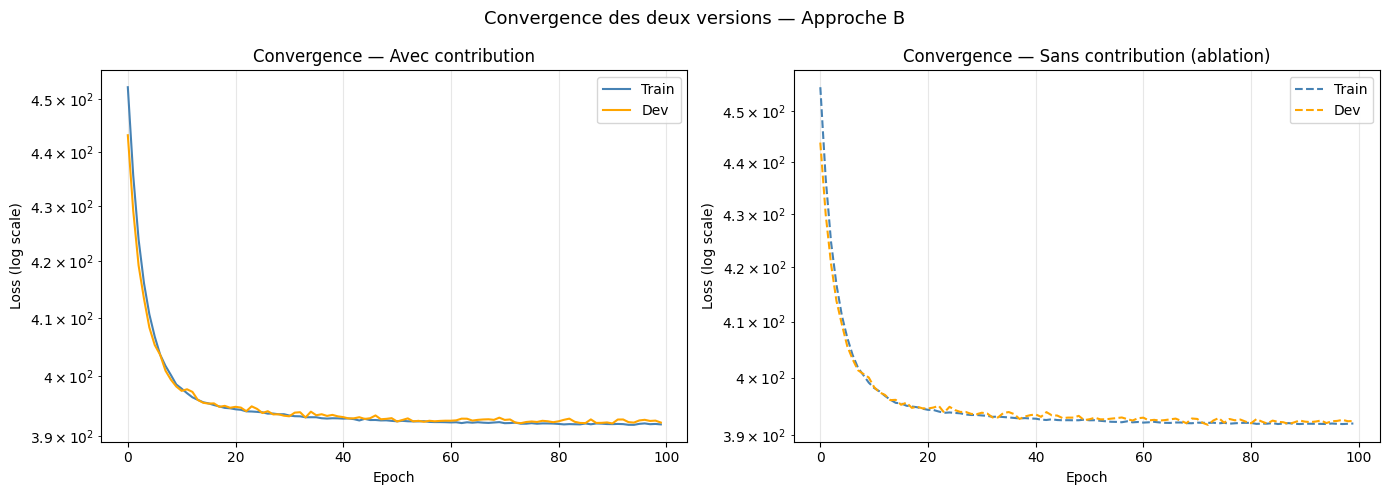

Loss train epoch 96 : 391.9798
Loss train epoch 100   : 391.8888
⚠️  La loss descend encore → le modèle n'a pas convergé, augmenter n_epochs


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_with['train'], label='Train', color='steelblue')
axes[0].plot(history_with['dev'],   label='Dev',   color='orange')
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Convergence — Avec contribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_without['train'], label='Train', color='steelblue', linestyle='--')
axes[1].plot(history_without['dev'],   label='Dev',   color='orange',    linestyle='--')
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Convergence — Sans contribution (ablation)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Convergence des deux versions — Approche B', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/convergence_approach_b.png', dpi=150)
plt.show()

# Diagnostic
last_train_with = history_with['train'][-1]
prev_train_with = history_with['train'][-5]
still_decreasing = last_train_with < prev_train_with

print(f"Loss train epoch {len(history_with['train'])-4} : {prev_train_with:.4f}")
print(f"Loss train epoch {len(history_with['train'])}   : {last_train_with:.4f}")
if still_decreasing:
    print("⚠️  La loss descend encore → le modèle n'a pas convergé, augmenter n_epochs")
else:
    print("✅  La loss a convergé")

# Cellule 14 — Courbes de loss comparatives


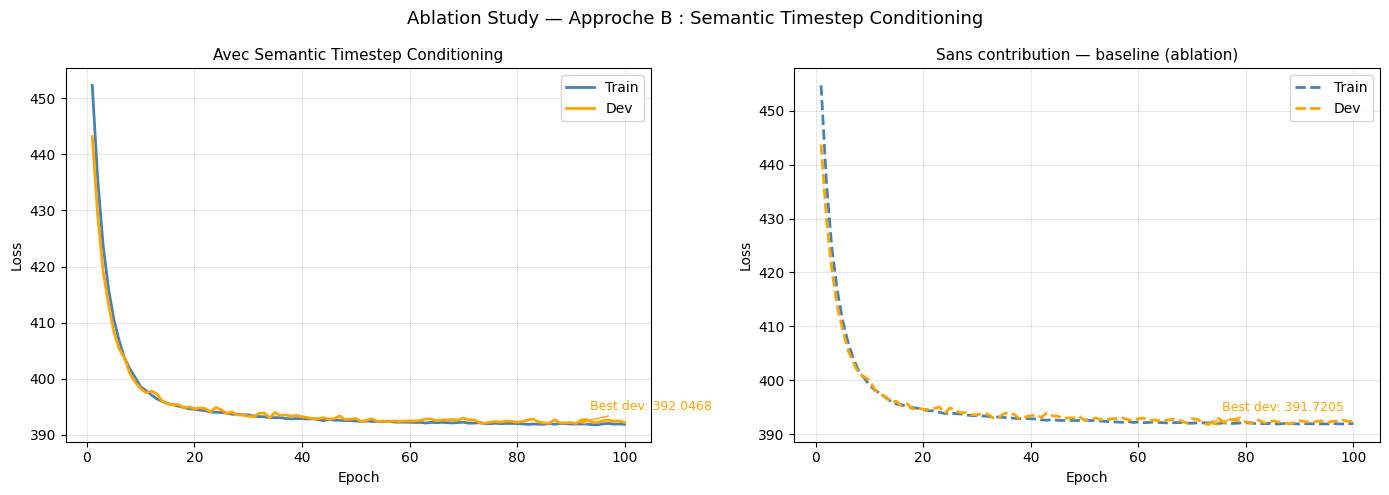

Meilleure dev loss AVEC contribution : 392.0468
Meilleure dev loss SANS contribution : 391.7205
Gain de notre contribution           : -0.3263


In [15]:
epochs = range(1, len(history_with['train']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avec contribution
axes[0].plot(epochs, history_with['train'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(epochs, history_with['dev'],   label='Dev',   color='orange',    linewidth=2)
axes[0].set_title('Avec Semantic Timestep Conditioning', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].annotate(f"Best dev: {min(history_with['dev']):.4f}",
                 xy=(np.argmin(history_with['dev']) + 1, min(history_with['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

# Sans contribution
axes[1].plot(epochs, history_without['train'], label='Train', color='steelblue',
             linewidth=2, linestyle='--')
axes[1].plot(epochs, history_without['dev'],   label='Dev',   color='orange',
             linewidth=2, linestyle='--')
axes[1].set_title('Sans contribution — baseline (ablation)', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].annotate(f"Best dev: {min(history_without['dev']):.4f}",
                 xy=(np.argmin(history_without['dev']) + 1, min(history_without['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

plt.suptitle('Ablation Study — Approche B : Semantic Timestep Conditioning', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curves_approach_b.png', dpi=150)
plt.show()

print(f"Meilleure dev loss AVEC contribution : {min(history_with['dev']):.4f}")
print(f"Meilleure dev loss SANS contribution : {min(history_without['dev']):.4f}")
print(f"Gain de notre contribution           : "
      f"{min(history_without['dev']) - min(history_with['dev']):+.4f}")

In [16]:
# Vérifier les plages de valeurs
batch = next(iter(dev_loader))
gt    = batch['poses']

input_ids      = batch['input_ids'].to(DEVICE)
attention_mask = batch['attention_mask'].to(DEVICE)
n_frames       = int(batch['pose_lengths'].float().mean().item())

with torch.no_grad():
    pred = model_with.generate(input_ids, attention_mask, n_frames=n_frames)

print(f"GT    — min: {gt.min():.4f}, max: {gt.max():.4f}, mean: {gt.mean():.4f}")
print(f"Pred  — min: {pred.min():.4f}, max: {pred.max():.4f}, mean: {pred.mean():.4f}")

GT    — min: -7.7385, max: 6.7415, mean: 0.0018
Pred  — min: -10.0000, max: 10.0000, mean: 0.0027


# Cellule 15 — MPJPE


In [17]:
@torch.no_grad()
def compute_mpjpe(model, loader, n_samples=200):
    model.eval()
    scores = []
    count  = 0
    for batch in tqdm(loader, desc="MPJPE", leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        gt_poses       = batch['poses'].to(DEVICE)
        pose_lengths   = batch['pose_lengths']
        B, T, K, _     = gt_poses.shape
        n_frames       = int(pose_lengths.float().mean().item())
        pred_poses     = model.generate(input_ids, attention_mask,
                                        n_frames=n_frames)
        min_T  = min(T, n_frames)
        dist   = torch.norm(pred_poses[:, :min_T] - gt_poses[:, :min_T], dim=-1)
        scores.append(dist.mean().item())
        count += B
        if count >= n_samples:
            break
    return np.mean(scores)


mpjpe_with    = compute_mpjpe(model_with,    dev_loader)
mpjpe_without = compute_mpjpe(model_without, dev_loader)
print(f"MPJPE AVEC contribution : {mpjpe_with:.4f}")
print(f"MPJPE SANS contribution : {mpjpe_without:.4f}")
print(f"Gain                    : {mpjpe_without - mpjpe_with:+.4f}")

MPJPE AVEC contribution : 17.0123
MPJPE SANS contribution : 17.0125
Gain                    : +0.0002


# Cellule 16 — Visualisation squelettes connectés


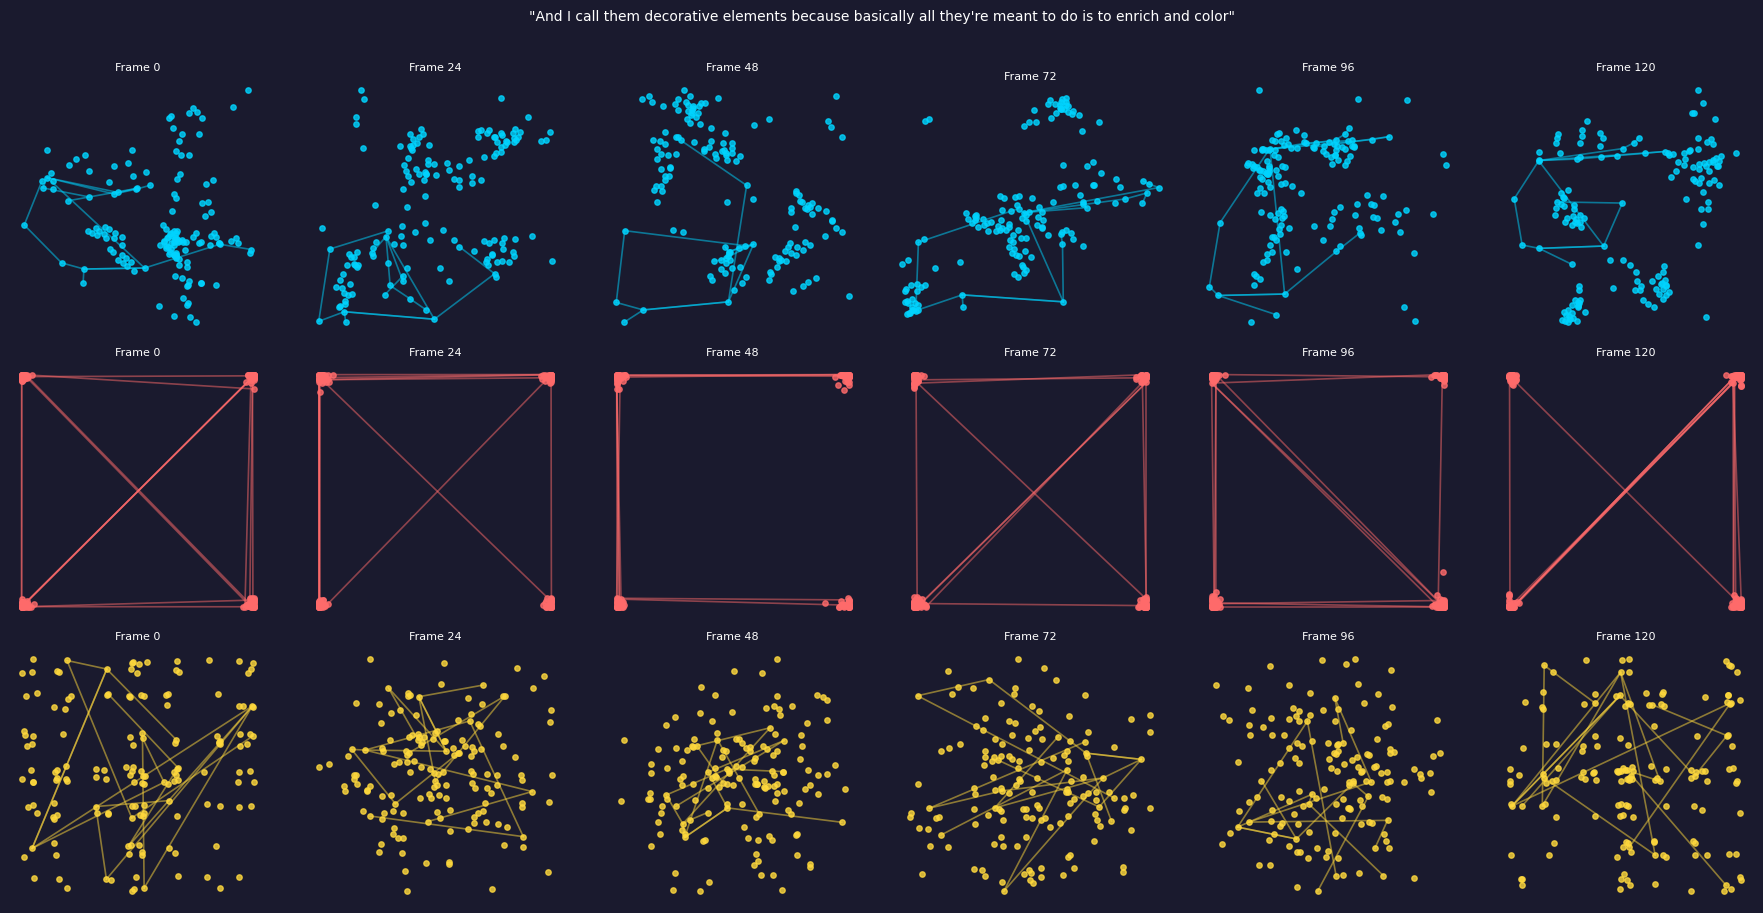

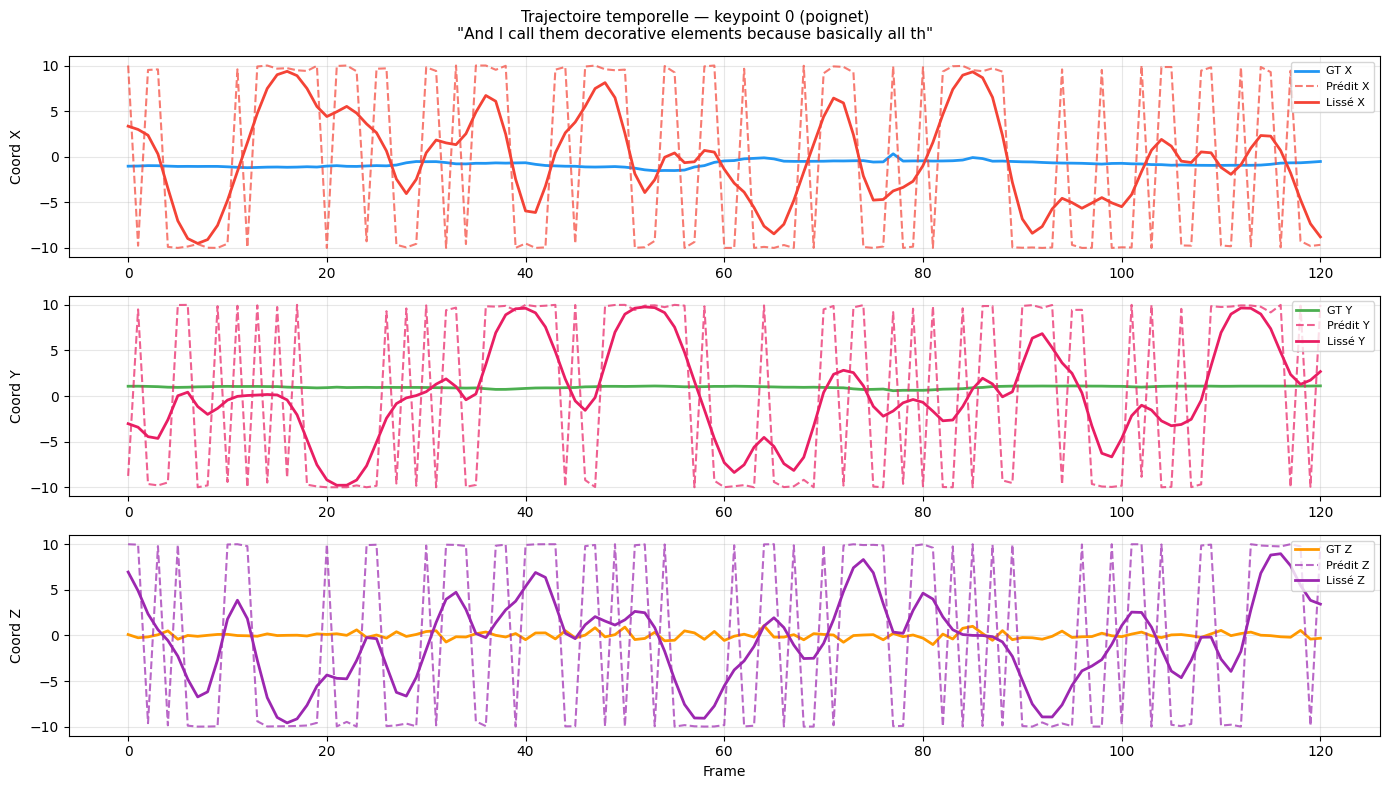

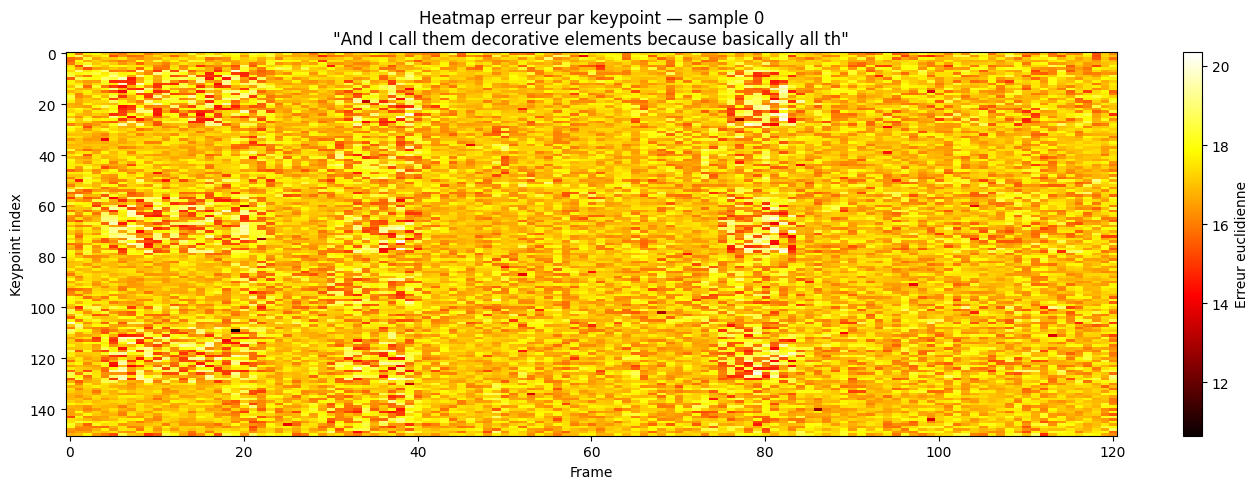

Séquence    : 121 frames
MPJPE brut  : 17.0023
MPJPE lissé : 7.0479
Keypoint le plus erroné : index 20 (erreur moy = 17.2232)


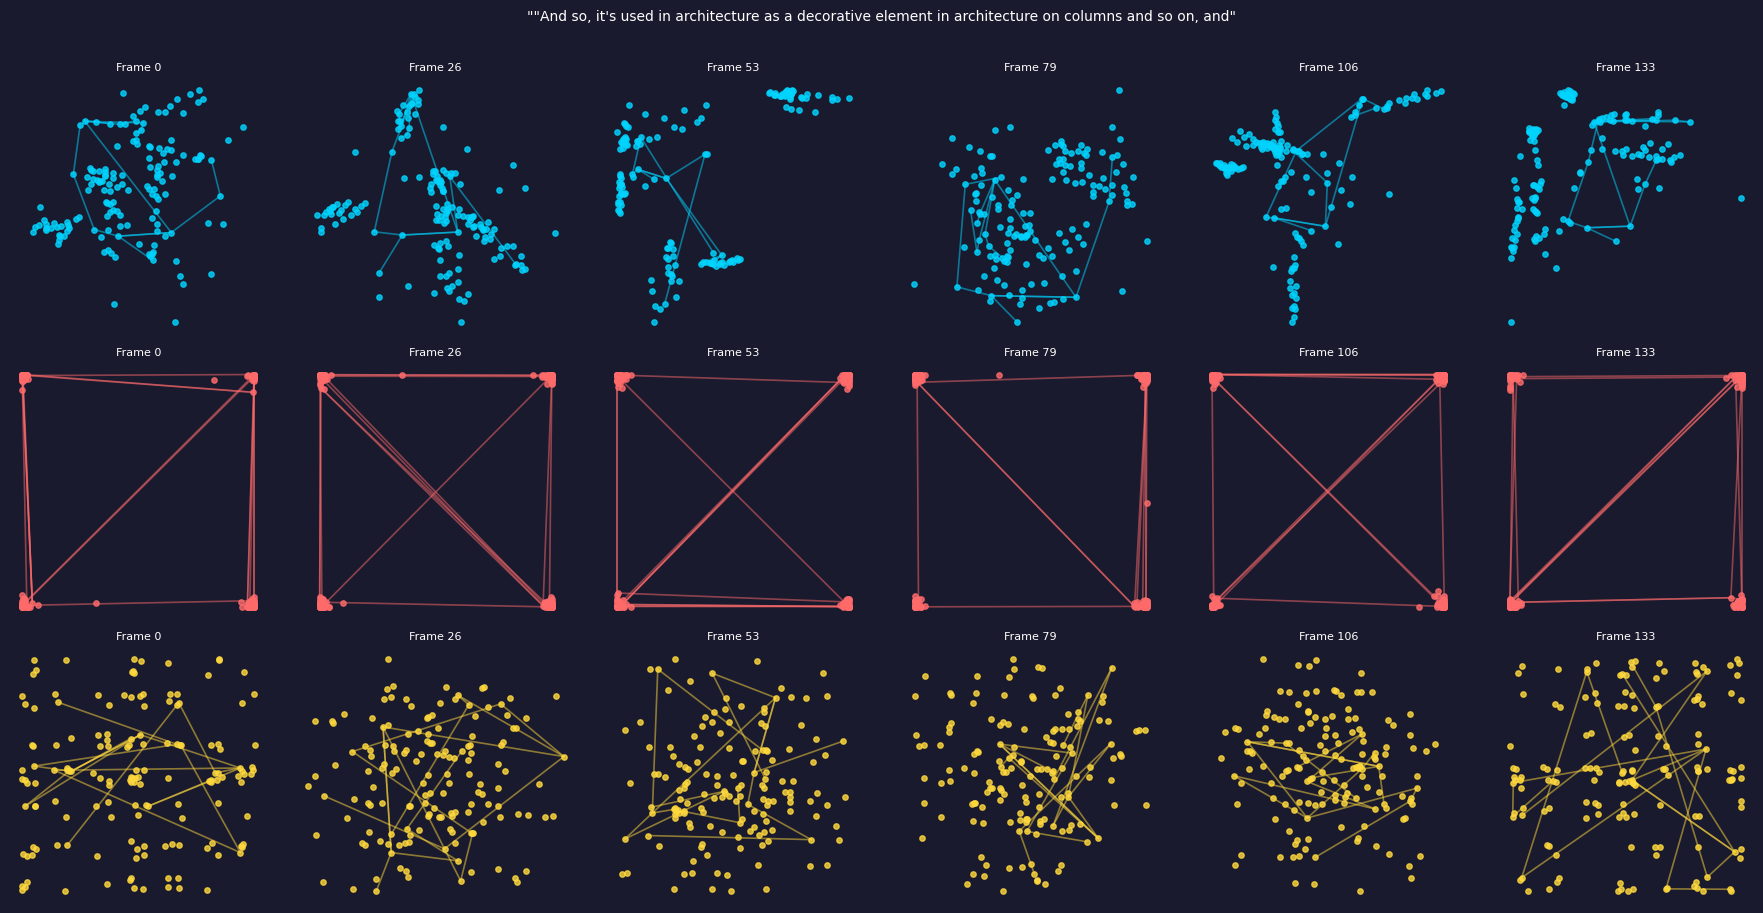

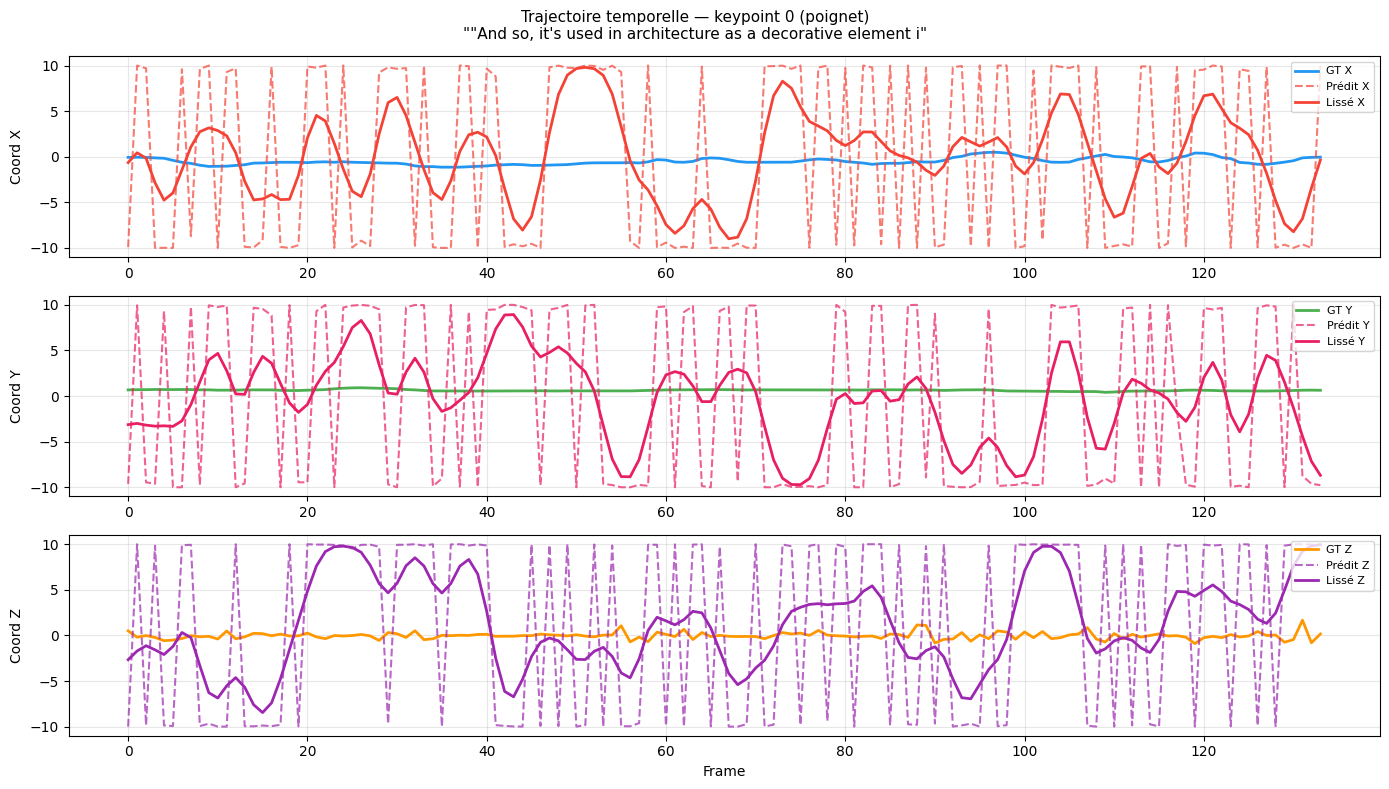

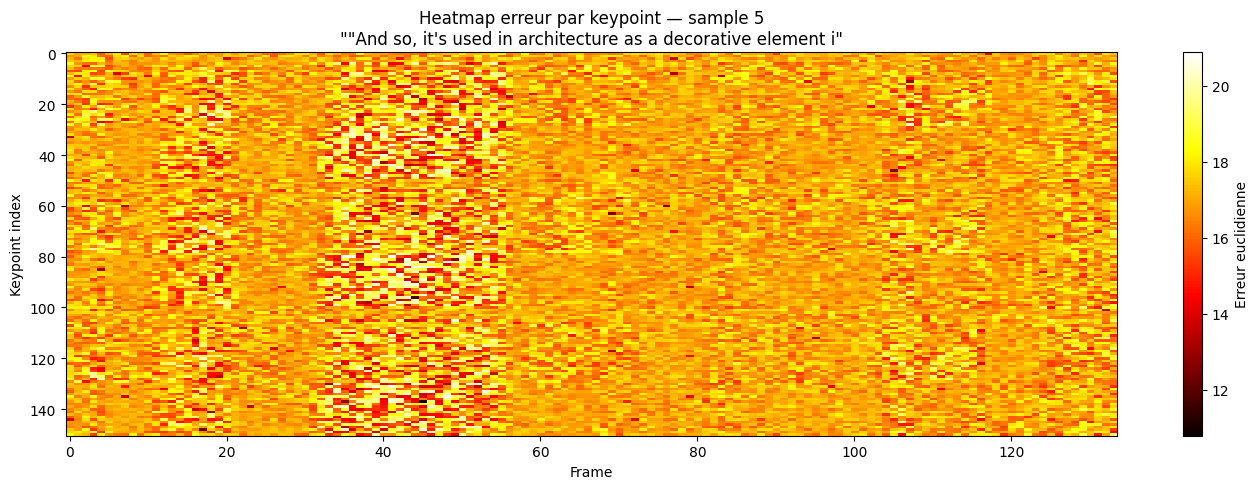

Séquence    : 134 frames
MPJPE brut  : 17.0242
MPJPE lissé : 7.1722
Keypoint le plus erroné : index 78 (erreur moy = 17.3099)


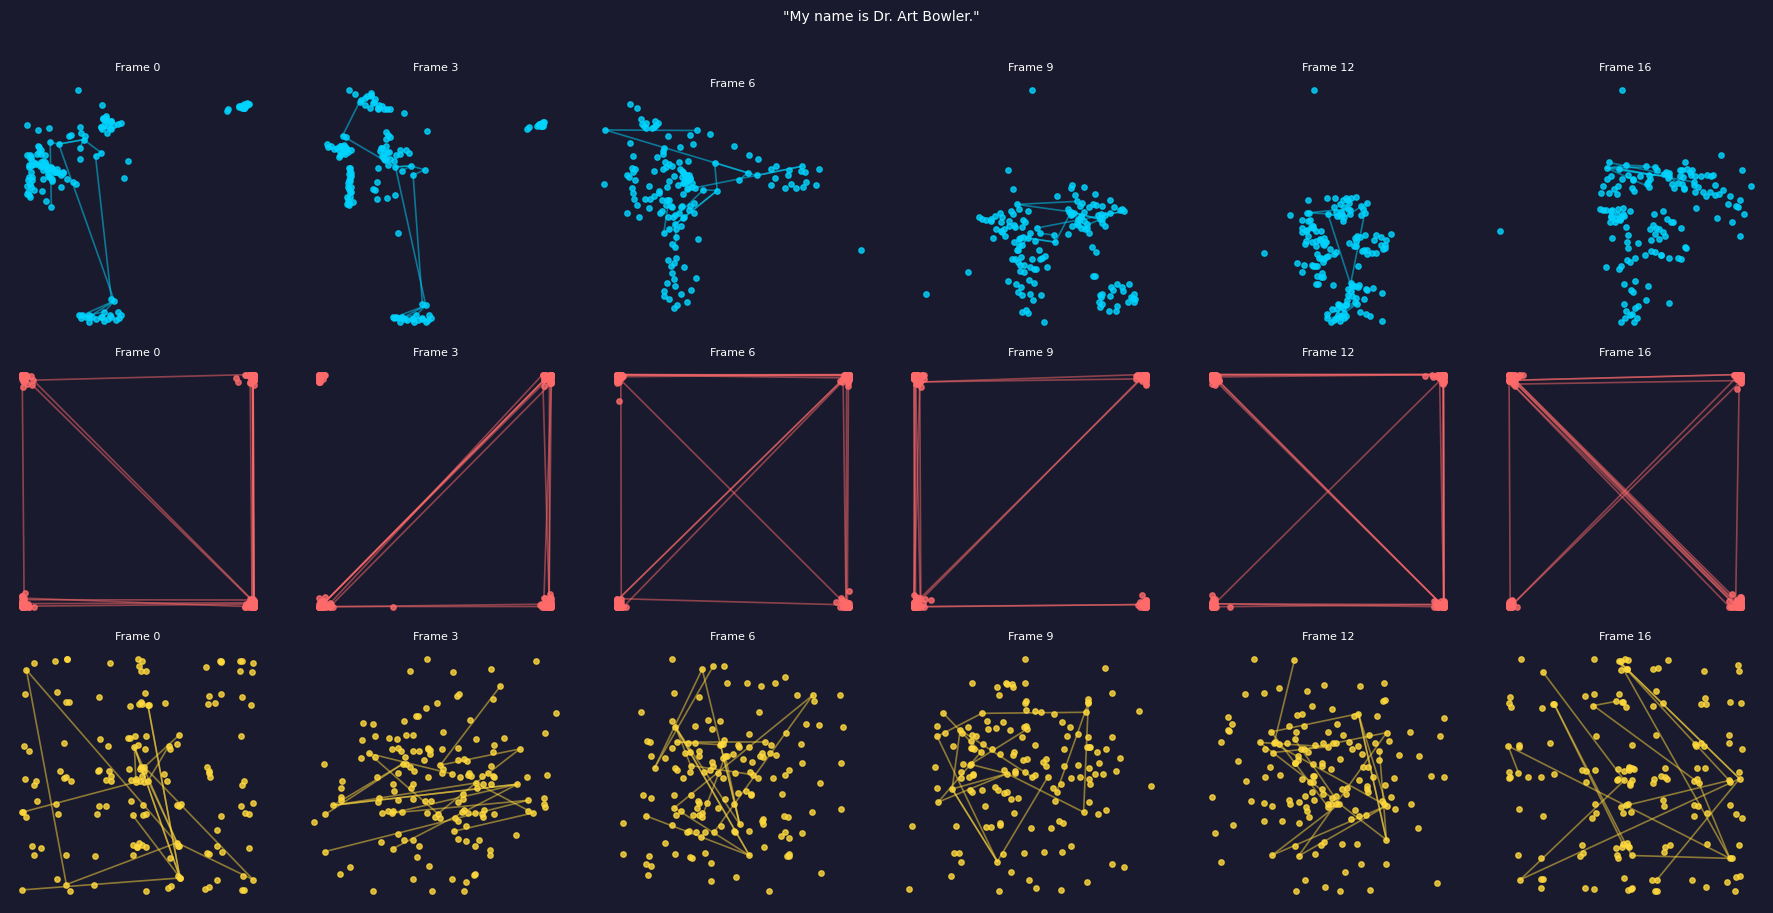

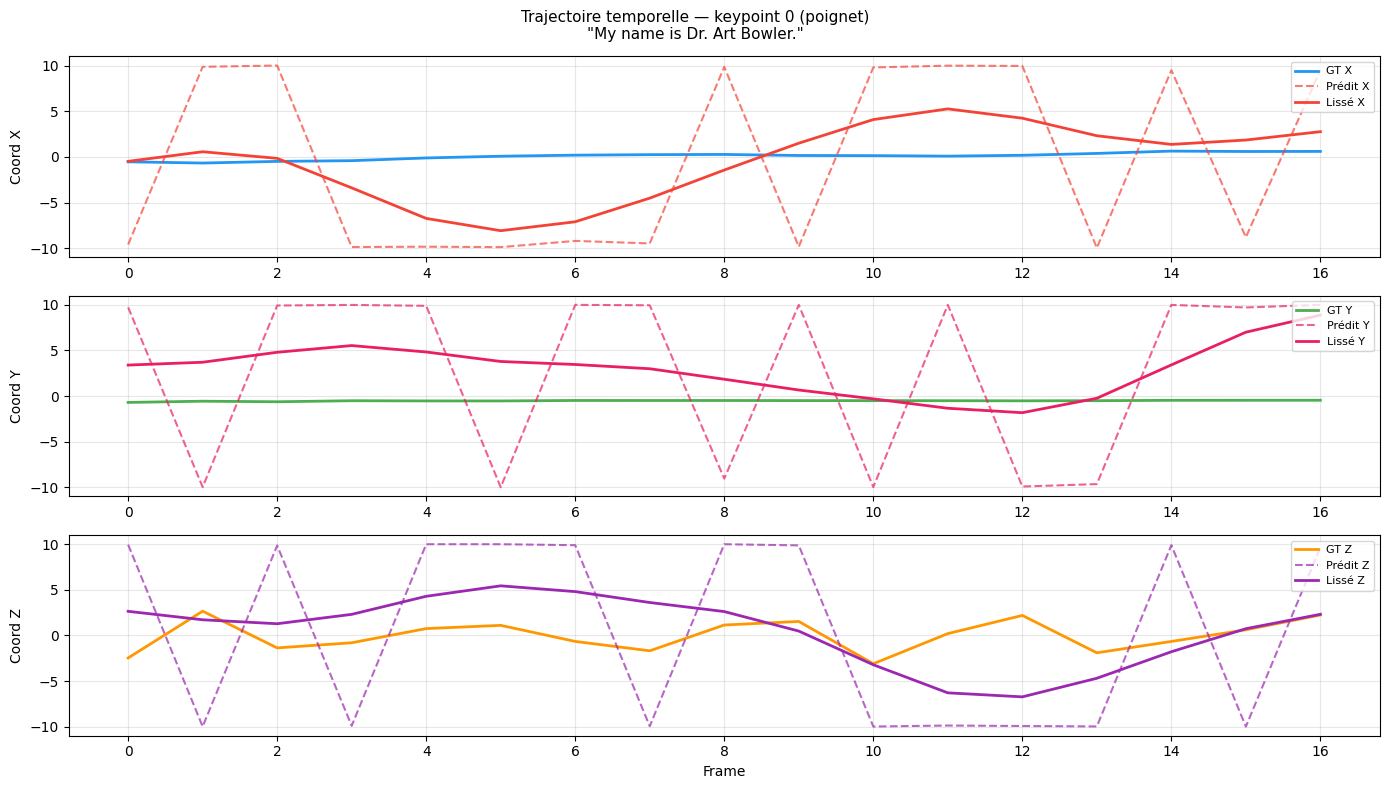

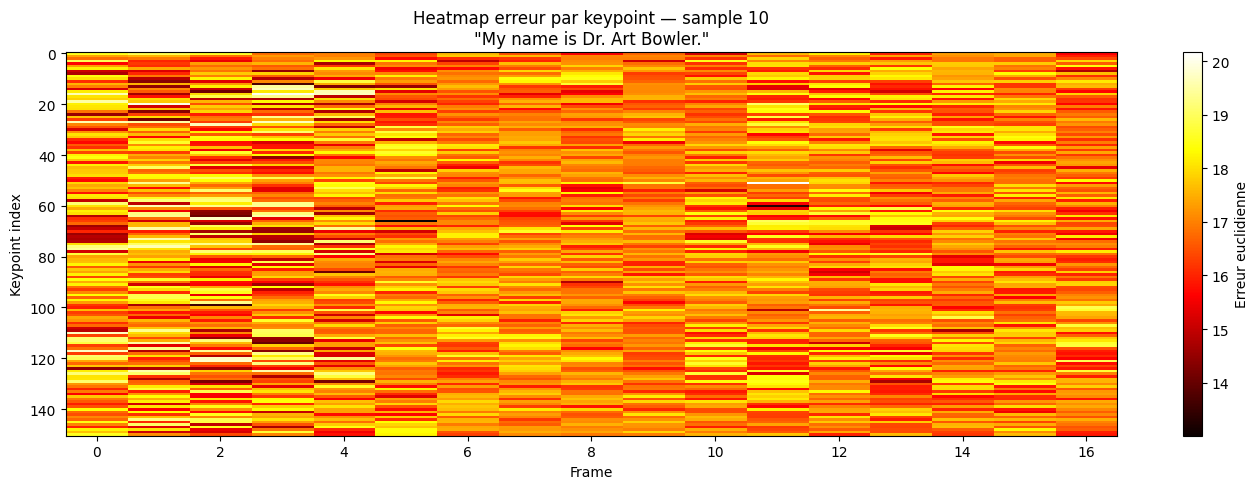

Séquence    : 17 frames
MPJPE brut  : 17.0224
MPJPE lissé : 7.5455
Keypoint le plus erroné : index 120 (erreur moy = 17.5388)


In [18]:
# ── Visualisation améliorée avec débruitage progressif et lissage ──

from scipy.ndimage import gaussian_filter1d

BODY_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (1,5),(5,6),(6,7),
    (1,2),(2,8),(8,9),(9,10),
    (8,11),(11,12),(12,13),
    (8,14),(14,15),(15,16),
]

def smooth_poses(poses, sigma=1.5):
    """Lisse les poses sur la dimension temporelle pour réduire le bruit"""
    smoothed = np.copy(poses)
    for kp in range(poses.shape[1]):
        for coord in range(poses.shape[2]):
            smoothed[:, kp, coord] = gaussian_filter1d(
                poses[:, kp, coord], sigma=sigma
            )
    return smoothed


def plot_skeleton_connected(ax, frame, color='steelblue', alpha=0.8):
    ax.scatter(frame[:, 0], -frame[:, 1],
               s=15, c=color, alpha=alpha, zorder=3)
    for (i, j) in BODY_CONNECTIONS:
        if i < len(frame) and j < len(frame):
            ax.plot([frame[i, 0], frame[j, 0]],
                    [-frame[i, 1], -frame[j, 1]],
                    c=color, alpha=0.5, linewidth=1.2, zorder=2)
    ax.axis('off')
    ax.set_aspect('equal')


@torch.no_grad()
def visualize_full(model, dataset, idx=0):
    model.eval()
    sample         = dataset[idx]
    input_ids      = sample['input_ids'].unsqueeze(0).to(DEVICE)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(DEVICE)
    gt_poses       = sample['poses'].numpy()       # (T, 151, 3)
    text           = sample['text']
    n_frames       = gt_poses.shape[0]
    pred_poses     = model.generate(input_ids, attention_mask,
                                    n_frames=n_frames)[0].cpu().numpy()
    pred_smoothed  = smooth_poses(pred_poses, sigma=1.5)

    n_show  = 6
    indices = np.linspace(0, min(len(gt_poses), len(pred_poses)) - 1,
                          n_show, dtype=int)

    # ── Plot 1 : GT vs Prédit vs Lissé ──────────────────────
    fig, axes = plt.subplots(3, n_show, figsize=(18, 9),
                              facecolor='#1a1a2e')
    fig.suptitle(f'"{text[:100]}"', fontsize=10, color='white', y=1.01)

    for col, fi in enumerate(indices):
        for row, (poses, color, label) in enumerate([
            (gt_poses,      '#00d4ff', 'Ground Truth'),
            (pred_poses,    '#ff6b6b', 'Généré (brut)'),
            (pred_smoothed, '#ffd93d', 'Généré (lissé)')
        ]):
            axes[row, col].set_facecolor('#1a1a2e')
            plot_skeleton_connected(axes[row, col], poses[fi], color=color)
            axes[row, col].set_title(f'Frame {fi}', fontsize=8, color='white')
            if col == 0:
                axes[row, col].set_ylabel(label, fontsize=10,
                                           color=color, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/viz_full_{idx}.png',
                dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()

    # ── Plot 2 : Trajectoire temporelle d'un keypoint ───────
    fig, axes = plt.subplots(3, 1, figsize=(14, 8))
    fig.suptitle(f'Trajectoire temporelle — keypoint 0 (poignet)\n"{text[:60]}"',
                 fontsize=11)

    coords     = ['X', 'Y', 'Z']
    colors_gt  = ['#2196F3', '#4CAF50', '#FF9800']
    colors_pred= ['#F44336', '#E91E63', '#9C27B0']

    for coord_idx in range(3):
        ax = axes[coord_idx]
        ax.plot(gt_poses[:, 0, coord_idx],
                color=colors_gt[coord_idx],
                label=f'GT {coords[coord_idx]}', linewidth=2)
        ax.plot(pred_poses[:, 0, coord_idx],
                color=colors_pred[coord_idx],
                label=f'Prédit {coords[coord_idx]}',
                linewidth=1.5, linestyle='--', alpha=0.7)
        ax.plot(pred_smoothed[:, 0, coord_idx],
                color=colors_pred[coord_idx],
                label=f'Lissé {coords[coord_idx]}',
                linewidth=2, linestyle='-', alpha=1.0)
        ax.set_ylabel(f'Coord {coords[coord_idx]}')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('Frame')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/trajectory_{idx}.png', dpi=150)
    plt.show()

    # ── Plot 3 : Heatmap de l'erreur par keypoint ───────────
    min_T   = min(len(gt_poses), len(pred_poses))
    errors  = np.linalg.norm(
        pred_poses[:min_T] - gt_poses[:min_T], axis=-1
    )  # (T, 151)

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(errors.T, aspect='auto', cmap='hot',
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Erreur euclidienne')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Keypoint index')
    ax.set_title(f'Heatmap erreur par keypoint — sample {idx}\n"{text[:60]}"')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/heatmap_{idx}.png', dpi=150)
    plt.show()

    # ── Stats ────────────────────────────────────────────────
    print(f"Séquence    : {n_frames} frames")
    print(f"MPJPE brut  : {errors.mean():.4f}")
    print(f"MPJPE lissé : {np.linalg.norm(pred_smoothed[:min_T] - gt_poses[:min_T], axis=-1).mean():.4f}")
    print(f"Keypoint le plus erroné : index {errors.mean(axis=0).argmax()} "
          f"(erreur moy = {errors.mean(axis=0).max():.4f})")


for idx in [0, 5, 10]:
    visualize_full(model_with, train_ds, idx=idx)

# Cellule 17 — Sauvegarder résultats et push


In [19]:
import os, csv

# Dossier de sortie
output_dir = '/kaggle/working/outputs_approach_b'
os.makedirs(output_dir, exist_ok=True)

# ── 1. Sauvegarder les checkpoints ──────────────────────────
torch.save(model_with.state_dict(),
           f'{output_dir}/model_with_contribution.pt')
torch.save(model_without.state_dict(),
           f'{output_dir}/model_without_contribution.pt')
print("✅ Checkpoints sauvegardés")

# ── 2. Sauvegarder les historiques de loss ──────────────────
import json
with open(f'{output_dir}/history_with.json', 'w') as f:
    json.dump(history_with, f)
with open(f'{output_dir}/history_without.json', 'w') as f:
    json.dump(history_without, f)
print("✅ Historiques de loss sauvegardés")

# ── 3. Sauvegarder les résultats dans results.csv ───────────
results_path = f'{output_dir}/results_approach_b.csv'
rows = [
    {
        'approach'       : 'B_with_contribution',
        'description'    : 'DDPM + Semantic Timestep Conditioning',
        'best_train_loss': round(min(history_with['train']),    4),
        'best_dev_loss'  : round(min(history_with['dev']),      4),
        'mpjpe_dev'      : round(mpjpe_with,                    4),
    },
    {
        'approach'       : 'B_without_contribution',
        'description'    : 'DDPM baseline ablation',
        'best_train_loss': round(min(history_without['train']), 4),
        'best_dev_loss'  : round(min(history_without['dev']),   4),
        'mpjpe_dev'      : round(mpjpe_without,                 4),
    }
]
with open(results_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print("✅ results_approach_b.csv sauvegardé")

# ── 4. Résumé final ─────────────────────────────────────────
print(f"\n{'='*50}")
print(f"Fichiers sauvegardés dans : {output_dir}")
print(f"{'='*50}")
for f in os.listdir(output_dir):
    size = os.path.getsize(f'{output_dir}/{f}') / 1024
    print(f"  {f:45s} {size:8.1f} KB")

✅ Checkpoints sauvegardés
✅ Historiques de loss sauvegardés
✅ results_approach_b.csv sauvegardé

Fichiers sauvegardés dans : /kaggle/working/outputs_approach_b
  results_approach_b.csv                             0.2 KB
  model_without_contribution.pt                 166880.0 KB
  model_with_contribution.pt                    166879.5 KB
  history_without.json                               3.8 KB
  history_with.json                                  3.8 KB
